In [ ]:
#run this for installing all necessary libraries
%pip install -q \
    langgraph \
    langchain \
    langchain-groq \
    langchain-community \
    chromadb \
    sqlalchemy \
    pandas \
    numpy \
    requests \
    python-dotenv \
    tenacity \
    kagglehub \
    matplotlib \
    seaborn \
    streamlit \
    rich

print("Installing all the requirements")

Note: you may need to restart the kernel to use updated packages.
Installing all the requirements


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
mediapipe 0.10.3 requires protobuf<4,>=3.11, but you have protobuf 6.33.6 which is incompatible.
wandb 0.19.1 requires protobuf!=4.21.0,!=5.28.0,<6,>=3.19.0; sys_platform != "linux", but you have protobuf 6.33.6 which is incompatible.
tensorflow-intel 2.12.0 requires numpy<1.24,>=1.22, but you have numpy 1.26.4 which is incompatible.
tensorflow-intel 2.12.0 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<5.0.0dev,>=3.20.3, but you have protobuf 6.33.6 which is incompatible.
tensorboard 2.12.2 requires google-auth-oauthlib<1.1,>=0.5, but you have google-auth-oauthlib 1.2.2 which is incompatible.
proto-plus 1.23.0 requires protobuf<5.0.0dev,>=3.19.0, but you have protobuf 6.33.6 which is incompatible.
jupyter-server 1.18.1 requires anyio<4,>=3.1.0, but you have anyio 4.12.1 which is incompati

In [1]:
import os
from pathlib import Path

ROOT = Path(r"C:\Users\MAITHILI\Care_Companion")

folders = [
    ROOT / "data" / "raw",
    ROOT / "data" / "processed",
    ROOT / "memory" / "chroma_db",
    ROOT / "memory" / "sqlite",
    ROOT / "tools",
    ROOT / "agent",
    ROOT / "evaluation",
    ROOT / "app",
]

for folder in folders:
    folder.mkdir(parents=True, exist_ok=True)

print("Folders created:")
for f in folders:
    print(f"  {f}")

Folders created:
  C:\Users\MAITHILI\Care_Companion\data\raw
  C:\Users\MAITHILI\Care_Companion\data\processed
  C:\Users\MAITHILI\Care_Companion\memory\chroma_db
  C:\Users\MAITHILI\Care_Companion\memory\sqlite
  C:\Users\MAITHILI\Care_Companion\tools
  C:\Users\MAITHILI\Care_Companion\agent
  C:\Users\MAITHILI\Care_Companion\evaluation
  C:\Users\MAITHILI\Care_Companion\app


In [ ]:
#this is for env file
env_content = """# CareCompanion AI — API Keys
# NEVER commit this file to GitHub

GROQ_API_KEY=************
USDA_API_KEY=************
NCBI_API_KEY=************
OPENFDA_API_KEY=************
"""

with open(ROOT / ".env", "w") as f:
    f.write(env_content)

gitignore = """.env
__pycache__/
*.pyc
memory/chroma_db/
memory/sqlite/
data/raw/
.ipynb_checkpoints/
"""
with open(ROOT / ".gitignore", "w") as f:
    f.write(gitignore)

print(f".env created at: {ROOT / '.env'}")
print()
print("Go fill in your keys now:")
print("  Groq (free, instant):  https://console.groq.com")
print("  USDA (free, instant):  https://fdc.nal.usda.gov/api-guide.html")
print("  PubMed (free):         https://www.ncbi.nlm.nih.gov/account/")
print("  OpenFDA:               no key needed, but register for higher limits")
print("    https://open.fda.gov/apis/authentication/")

.env created at: C:\Users\MAITHILI\Care_Companion\.env

Go fill in your keys now:
  Groq (free, instant):  https://console.groq.com
  USDA (free, instant):  https://fdc.nal.usda.gov/api-guide.html
  PubMed (free):         https://www.ncbi.nlm.nih.gov/account/
  OpenFDA:               no key needed, but register for higher limits
    https://open.fda.gov/apis/authentication/


In [ ]:
import os
from pathlib import Path

ROOT = Path(r"C:\Users\MAITHILI\Care_Companion")

# Create all folders for the project
folders = [
    ROOT / "data" / "raw",
    ROOT / "data" / "processed",
    ROOT / "memory" / "chroma_db",
    ROOT / "memory" / "sqlite",
    ROOT / "tools",
    ROOT / "agent",
    ROOT / "evaluation",
    ROOT / "app",
]

for folder in folders:
    folder.mkdir(parents=True, exist_ok=True)

print("Folders created:")
for f in folders:
    print(f"  {f}")

lines = [
    "GROQ_API_KEY=************\n",
    "USDA_API_KEY=************\n",
    "NCBI_API_KEY=************\n",
    "OPENFDA_API_KEY=************\n",
]

with open(ROOT / ".env", "w", encoding="utf-8") as f:
    f.writelines(lines)

print(f"\n.env created at: {ROOT / '.env'}")

Folders created:
  C:\Users\MAITHILI\Care_Companion\data\raw
  C:\Users\MAITHILI\Care_Companion\data\processed
  C:\Users\MAITHILI\Care_Companion\memory\chroma_db
  C:\Users\MAITHILI\Care_Companion\memory\sqlite
  C:\Users\MAITHILI\Care_Companion\tools
  C:\Users\MAITHILI\Care_Companion\agent
  C:\Users\MAITHILI\Care_Companion\evaluation
  C:\Users\MAITHILI\Care_Companion\app

.env created at: C:\Users\MAITHILI\Care_Companion\.env


In [ ]:
import os

os.environ["GROQ_API_KEY"]    = "************"
os.environ["USDA_API_KEY"]    = "************"
os.environ["NCBI_API_KEY"]    = "************"
os.environ["OPENFDA_API_KEY"] = "************"

print("Keys loaded:")
for k in ["GROQ_API_KEY", "USDA_API_KEY", "NCBI_API_KEY", "OPENFDA_API_KEY"]:
    val = os.environ.get(k, "")
    print(f"  {k:20s}: {'SET' if val else 'EMPTY'}")

Keys loaded:
  GROQ_API_KEY        : SET
  USDA_API_KEY        : SET
  NCBI_API_KEY        : SET
  OPENFDA_API_KEY     : SET


In [ ]:
#loading the dataset

import pandas as pd
import numpy as np

try:
    import kagglehub
    path = kagglehub.dataset_download("uciml/pima-indians-diabetes-database")
    pima_path = list(Path(path).glob("*.csv"))[0]
    print(f"Downloaded to: {pima_path}")

except Exception as e:
    # data from https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database
    
    pima_path = ROOT / "data" / "raw" / "diabetes.csv"
    print(f"kagglehub failed: {e}")
    print(f"Place diabetes.csv manually at: {pima_path}")

df = pd.read_csv(pima_path)
print(f"\nLoaded: {df.shape[0]} patients, {df.shape[1]} columns")
print(df.head())

Downloaded to: C:\Users\MAITHILI\.cache\kagglehub\datasets\uciml\pima-indians-diabetes-database\versions\1\diabetes.csv

Loaded: 768 patients, 9 columns
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


In [6]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [7]:
df.shape

(768, 9)

In [8]:
print("Column meanings:")
print("-" * 50)
info = {
    "Pregnancies":              "Number of pregnancies",
    "Glucose":                  "Plasma glucose (mg/dL)",
    "BloodPressure":            "Diastolic BP (mm Hg)",
    "SkinThickness":            "Triceps skin fold (mm)",
    "Insulin":                  "2-Hour serum insulin",
    "BMI":                      "Body mass index",
    "DiabetesPedigreeFunction": "Hereditary likelihood score",
    "Age":                      "Age in years",
    "Outcome":                  "1=diabetic, 0=not diabetic",
}
for col, desc in info.items():
    print(f"  {col:30s} {desc}")

print()
print(df.describe().round(2))
print()
print(f"Diabetic:     {df['Outcome'].sum()} ({df['Outcome'].mean()*100:.1f}%)")
print(f"Non-diabetic: {(df['Outcome']==0).sum()} ({(df['Outcome']==0).mean()*100:.1f}%)")

Column meanings:
--------------------------------------------------
  Pregnancies                    Number of pregnancies
  Glucose                        Plasma glucose (mg/dL)
  BloodPressure                  Diastolic BP (mm Hg)
  SkinThickness                  Triceps skin fold (mm)
  Insulin                        2-Hour serum insulin
  BMI                            Body mass index
  DiabetesPedigreeFunction       Hereditary likelihood score
  Age                            Age in years
  Outcome                        1=diabetic, 0=not diabetic

       Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin     BMI  \
count       768.00   768.00         768.00         768.00   768.00  768.00   
mean          3.85   120.89          69.11          20.54    79.80   31.99   
std           3.37    31.97          19.36          15.95   115.24    7.88   
min           0.00     0.00           0.00           0.00     0.00    0.00   
25%           1.00    99.00          62.00        

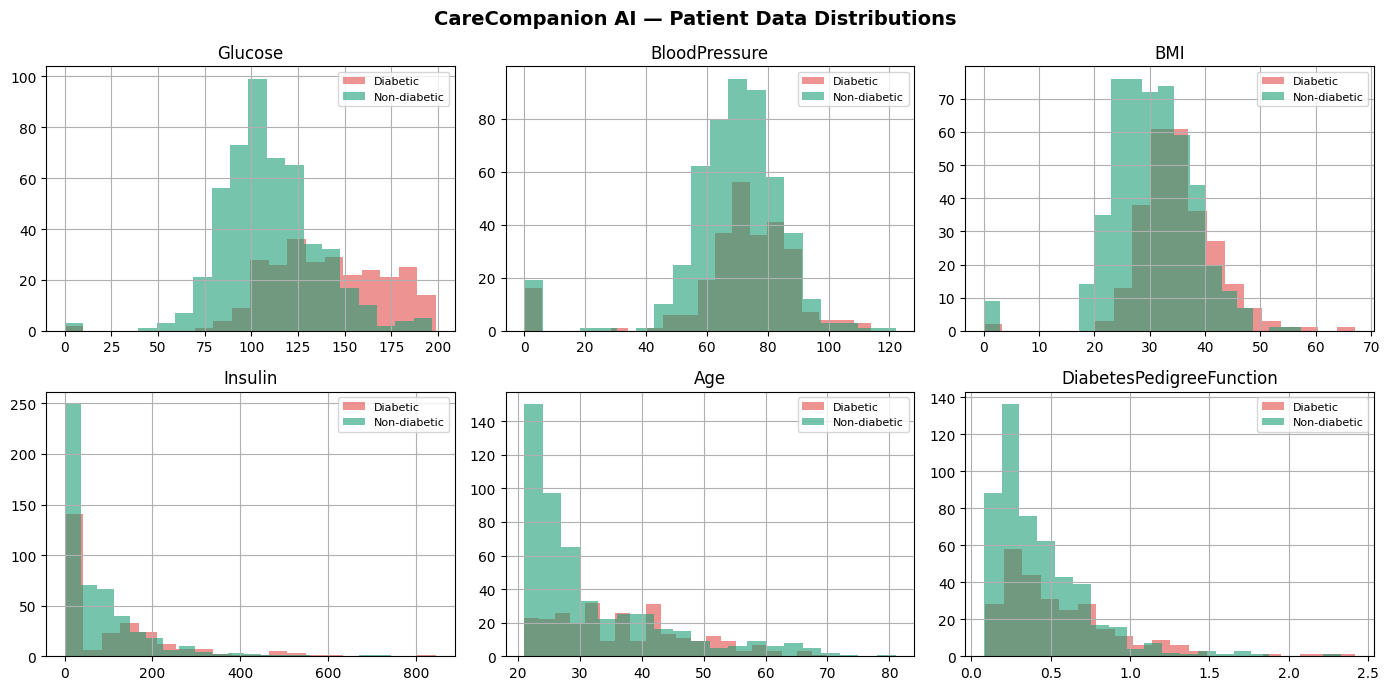

Plot saved.


In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
fig.suptitle("CareCompanion AI — Patient Data Distributions", 
             fontsize=14, fontweight="bold")

cols = ["Glucose", "BloodPressure", "BMI", 
        "Insulin", "Age", "DiabetesPedigreeFunction"]

for ax, col in zip(axes.flatten(), cols):
    df[df["Outcome"]==1][col].hist(ax=ax, alpha=0.6, 
                                    color="#E24B4A", 
                                    label="Diabetic", bins=20)
    df[df["Outcome"]==0][col].hist(ax=ax, alpha=0.6, 
                                    color="#1D9E75", 
                                    label="Non-diabetic", bins=20)
    ax.set_title(col)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(ROOT / "data" / "processed" / "distributions.png", dpi=120)
plt.show()
print("Plot saved.")

In [ ]:
df_clean = df.copy()

fix_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

for col in fix_cols:
    zeros = (df_clean[col] == 0).sum()
    if zeros > 0:
        median_val = df_clean[df_clean[col] != 0][col].median()
        df_clean[col] = df_clean[col].replace(0, median_val)
        print(f"  {col:20s}: fixed {zeros} zeros -> median {median_val:.1f}")

save_path = ROOT / "data" / "processed" / "diabetes_clean.csv"
df_clean.to_csv(save_path, index=False)
print(f"\nClean dataset saved: {save_path}")
print(f"Shape: {df_clean.shape}")

  Glucose             : fixed 5 zeros -> median 117.0
  BloodPressure       : fixed 35 zeros -> median 72.0
  SkinThickness       : fixed 227 zeros -> median 29.0
  Insulin             : fixed 374 zeros -> median 125.0
  BMI                 : fixed 11 zeros -> median 32.3

Clean dataset saved: C:\Users\MAITHILI\Care_Companion\data\processed\diabetes_clean.csv
Shape: (768, 9)


In [ ]:
import requests

results = {}

#Groq
try:
    from langchain_groq import ChatGroq
    llm = ChatGroq(
        model="llama-3.3-70b-versatile",  
        temperature=0.1,
        api_key=os.environ["GROQ_API_KEY"]
    )
    r = llm.invoke("Reply with exactly: Groq OK")
    results["Groq"] = f"CONNECTED — {r.content.strip()}"
except Exception as e:
    results["Groq"] = f"FAILED — {e}"

#OpenFDA
try:
    r = requests.get(
        "https://api.fda.gov/drug/label.json",
        params={"search": 'openfda.generic_name:"metformin"', "limit": 1},
        timeout=10
    )
    name = r.json()["results"][0]["openfda"]["generic_name"][0]
    results["OpenFDA"] = f"CONNECTED — fetched: {name}"
except Exception as e:
    results["OpenFDA"] = f"FAILED — {e}"

#RxNorm
try:
    r = requests.get(
        "https://rxnav.nlm.nih.gov/REST/rxcui.json",
        params={"name": "metformin"},
        timeout=10
    )
    rxcui = r.json()["idGroup"]["rxnormId"][0]
    results["RxNorm"] = f"CONNECTED — metformin RxCUI={rxcui}"
except Exception as e:
    results["RxNorm"] = f"FAILED — {e}"

#USDA
try:
    r = requests.get(
        "https://api.nal.usda.gov/fdc/v1/foods/search",
        params={
            "query":    "apple",
            "pageSize": 1,
            "api_key":  os.environ.get("USDA_API_KEY", "DEMO_KEY")
        },
        timeout=15
    )
    food = r.json()["foods"][0]["description"]
    results["USDA"] = f"CONNECTED — found: {food[:40]}"
except Exception as e:
    results["USDA"] = f"FAILED — {e}"

#PubMed
try:
    r = requests.get(
        "https://eutils.ncbi.nlm.nih.gov/entrez/eutils/esearch.fcgi",
        params={
            "db":      "pubmed",
            "term":    "metformin type 2 diabetes",
            "retmax":  1,
            "retmode": "json"
        },
        timeout=10
    )
    count = r.json()["esearchresult"]["count"]
    results["PubMed"] = f"CONNECTED — {count} papers found"
except Exception as e:
    results["PubMed"] = f"FAILED — {e}"

#ChromaDB
try:
    import chromadb
    client = chromadb.PersistentClient(
        path=str(ROOT / "memory" / "chroma_db")
    )
    col = client.get_or_create_collection("test")
    col.add(documents=["hello"], ids=["t1"])
    col.query(query_texts=["hello"], n_results=1)
    client.delete_collection("test")
    results["ChromaDB"] = "CONNECTED — vector store working"
except Exception as e:
    results["ChromaDB"] = f"FAILED — {e}"

#results
print("=" * 55)
print("API CONNECTION RESULTS")
print("=" * 55)
for name, status in results.items():
    icon = "OK  " if "CONNECTED" in status else "FAIL"
    print(f"  [{icon}] {name:12s}: {status}")

print()
all_good = all("CONNECTED" in v for v in results.values())
if all_good:
    print("All 6 connected.")
else:
    print("Still failing")

API CONNECTION RESULTS
  [OK  ] Groq        : CONNECTED — Groq OK
  [OK  ] OpenFDA     : CONNECTED — fetched: SITAGLIPTIN AND METFORMIN HYDROCHLORIDE
  [OK  ] RxNorm      : CONNECTED — metformin RxCUI=6809
  [OK  ] USDA        : CONNECTED — found: APPLE
  [OK  ] PubMed      : CONNECTED — 16318 papers found
  [OK  ] ChromaDB    : CONNECTED — vector store working

All 6 connected.


In [12]:
import json
from datetime import datetime

DIABETES_MEDS = [
    [{"name": "Metformin",        "dose": "500mg",     "frequency": "twice daily"}],
    [{"name": "Metformin",        "dose": "1000mg",    "frequency": "twice daily"},
     {"name": "Glipizide",        "dose": "5mg",       "frequency": "once daily"}],
    [{"name": "Metformin",        "dose": "500mg",     "frequency": "twice daily"},
     {"name": "Lisinopril",       "dose": "10mg",      "frequency": "once daily"}],
    [{"name": "Insulin Glargine", "dose": "20 units",  "frequency": "once daily"}],
    [{"name": "Sitagliptin",      "dose": "100mg",     "frequency": "once daily"}],
]

NAMES    = ["Sarah","James","Maria","David","Linda","Carlos","Emma",
            "Michael","Priya","Robert","Angela","Kevin","Susan","Ahmed",
            "Nicole","Thomas","Grace","Daniel","Patricia","Marcus"]
INSURANCE = ["none", "medicaid", "private"]
ACTIVITY  = ["sedentary", "light", "moderate", "active"]
DIETS     = [["low-carb"], ["vegetarian"], ["standard"], ["mediterranean"]]
BUDGETS   = [75, 100, 150, 200, 300]

diabetic_df = df_clean[df_clean["Outcome"] == 1].reset_index(drop=True)
np.random.seed(42)

patients = []
for i in range(20):
    row = diabetic_df.iloc[i % len(diabetic_df)]
    p = {
        "patient_id":       f"p{i+1:03d}",
        "name":             NAMES[i],
        "age":              int(row["Age"]),
        "created_at":       datetime.now().isoformat(),
        "last_seen":        datetime.now().isoformat(),
        "conditions":       ["Type 2 Diabetes"],
        "medications":      DIABETES_MEDS[i % len(DIABETES_MEDS)],
        "allergies":        [],
        "recent_glucose":   round(float(row["Glucose"]), 1),
        "recent_a1c":       round(float(row["Glucose"]) / 28.7 + 2.15, 1),
        "recent_bmi":       round(float(row["BMI"]), 1),
        "diet_preferences": DIETS[i % len(DIETS)],
        "foods_to_avoid":   [],
        "activity_level":   ACTIVITY[i % len(ACTIVITY)],
        "budget_monthly":   float(np.random.choice(BUDGETS)),
        "insurance":        INSURANCE[i % len(INSURANCE)],
        "session_count":    0,
        "agent_notes":      [],
        "last_fda_check":   None,
    }
    patients.append(p)

eval_path = ROOT / "evaluation" / "test_patients.json"
with open(eval_path, "w", encoding="utf-8") as f:
    json.dump(patients, f, indent=2)

print(f"Generated {len(patients)} test patients -> {eval_path}")
print()
print(f"{'Name':10s} {'Age':4s} {'Glucose':8s} {'BMI':6s} Medications")
print("-" * 65)
for p in patients[:5]:
    meds = ", ".join(m["name"] for m in p["medications"])
    print(f"{p['name']:10s} {p['age']:4d} {p['recent_glucose']:8.1f} "
          f"{p['recent_bmi']:6.1f}  {meds}")
print(f"  ... and {len(patients)-5} more saved to file")

Generated 20 test patients -> C:\Users\MAITHILI\Care_Companion\evaluation\test_patients.json

Name       Age  Glucose  BMI    Medications
-----------------------------------------------------------------
Sarah        50    148.0   33.6  Metformin
James        32    183.0   23.3  Metformin, Glipizide
Maria        33    137.0   43.1  Metformin, Lisinopril
David        26     78.0   31.0  Insulin Glargine
Linda        53    197.0   30.5  Sitagliptin
  ... and 15 more saved to file
